# Cosmology constraints using SN data from Pantheon

El propósito es realizar una versión simplificada del análisis presentado en https://arxiv.org/pdf/2202.04077.
La documentación para los datos de Pantheon + SH0ES está en: https://github.com/PantheonPlusSH0ES/DataRelease/tree/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR.

### Columnas importantes para el análisis
- m_b_corr: corrected/standarized m_b magnitude.
- c: SALT2 color.
- x1: SALT2 stretch.
- zHD: Hubble Diagram Redshift (with CMB and VPEC corrections).
- biasCor_m_b: Bias correction applied to brightness m_b.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import emcee
from tqdm import tqdm
import corner
from numba import njit
plt.rcParams['axes.axisbelow'] = True       ## Fijar parámetros de plots
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
data_head = pd.read_csv('Pantheon+SH0ES.dat', sep=r"\s+")

In [3]:
#data_head.head()

Generamos un archivo más ligero con las columnas que nos interesan y graficamos la magnitud aparente

In [4]:
data = data_head[['zHD', 'm_b_corr', 'c', 'x1', 'biasCor_m_b', 'mB']]
data.to_csv("data.dat",sep=" ",index=False,header=False)

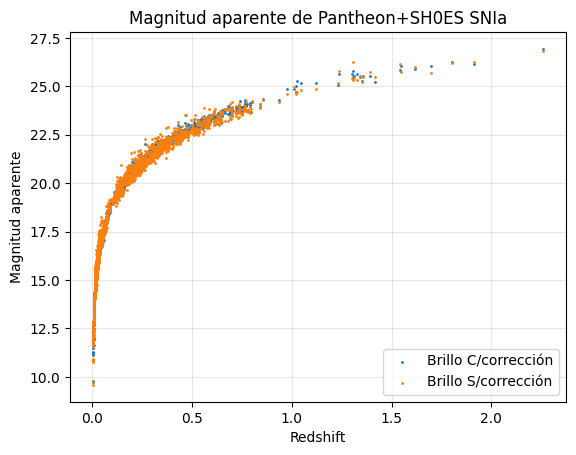

In [5]:
plt.scatter(data['zHD'], data['m_b_corr'], s = 1, label='Brillo C/corrección')
plt.scatter(data['zHD'], data['mB'], s = 1, label='Brillo S/corrección')
plt.title('Magnitud aparente de Pantheon+SH0ES SNIa')
plt.xlabel('Redshift')
plt.ylabel('Magnitud aparente')
plt.legend(loc='lower right')

Usaremos los datos "mB", ya que "m_b_corr" son datos de brillo ya corregidos.

## Modelo $vs.$ datos
### --- Modelo ---
Utilizando la librería $\textit{astropy}$, podemos calcular la distancia módulo para todos los valores de z desponibles en los datos. Ese será nuestro modelo. 

La $\textbf{distancia modulo del modelo}$ teórica (la que será nuestro modelo), la calcularemos de la siguiente manera:
\begin{equation}
\mu_{modelo} (z_i) = 5 \log (d_L(z_i)/10pc)
\end{equation}
donde $d_L$ es la distancia luminosa y $H(z)$ es parámetro de Hubble. La librería $\textit{astropy}$ nos ayudará a resolver, para un $H_0$ fijo, la integral
\begin{equation}
d_L(z) = (1+z)c \int_0^z \frac{dz´}{H_0 \sqrt{\Omega_M(1+z')^3 + \Omega_{\Lambda}(1+z')^{3(1+w)}}}
\end{equation}

In [6]:
from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import WMAP9           ## Obtenemos algunos valores de WMAP

In [7]:
#WMAP9?

In [8]:
H0_units = WMAP9.H(0)
H_0 = H0_units.value
Tcmb0_units = WMAP9.Tcmb(0)
Tcmb_0 = Tcmb0_units.value
print(H_0, Tcmb_0)

69.32 2.725


In [9]:
#FlatLambdaCDM?

In [10]:
cosmo = FlatLambdaCDM(H0 = H_0, Tcmb0 = Tcmb_0, Om0=0.3)

In [11]:
dc = cosmo.comoving_distance(z=10)
dc

<Quantity 9528.45961505 Mpc>

In [12]:
dl = cosmo.luminosity_distance(z=10).value   
#dl

In [13]:
def Lum_dist (z):
    return cosmo.luminosity_distance(z).value

In [14]:
def mu_datos(z, H, Tcmb):
    dl = Lum_dist(z)
    return 5*np.log10(dl*100000)   ## La distancia modulo está en Mpc, hay que multiplicar la formula por 1M

Obtenemos la distancia modulo teórica que vamos a comparar para hace el ajuste

In [15]:
z = data['zHD'].to_numpy()
mu_i = mu_datos(data['zHD'], H_0, Tcmb_0)
#mu_i

Text(0, 0.5, '$\\mu_{modelo}$')

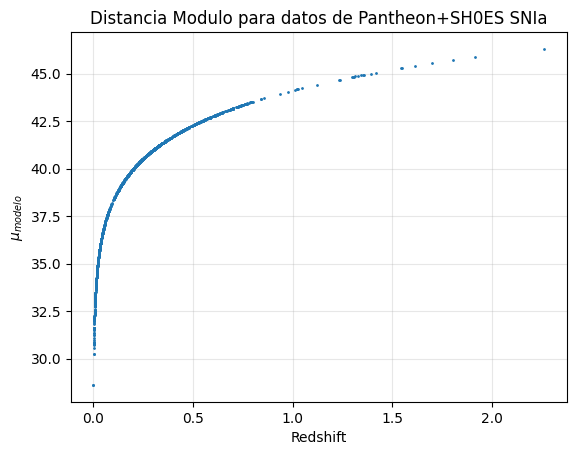

In [16]:
plt.scatter(z, mu_i, s = 1)
plt.title('Distancia Modulo para datos de Pantheon+SH0ES SNIa')
plt.xlabel('Redshift')
plt.ylabel(r'$\mu_{modelo}$')

### --- Datos ---
Para los datos hay que minimizar un $\chi^2$ donde:
\begin{equation}
-2 \ln (\mathcal{L}) = \chi^2 = \Delta\vec{D}^{T} \hspace{0.2cm} C^{-1}_{STAT} \hspace{0.2cm} \Delta \vec{D}
\end{equation}
con $\vec{D}$ el vector de 1701 restas de distancias modulos calculadas como
\begin{equation}
\Delta D_i = \mu_i - \mu_{modelo}
\end{equation}
Entonces, para formar los vectores, a continuación obtenemos los valores de la matriz de covarianza.


#### Distancia modulo

El modelo de distancia modulo que utlizamos está dado por la ec. (1) del artículo de $\textit{The Pantheon+ Analysis}$
\begin{equation}
\mu_{model} = m_B + \alpha x_1 - \beta c - M -\delta_{bias} + \delta_{shots},
\end{equation}
Como primera aproximación, tomaremos únicamente el modelo
\begin{equation}
\mu_{model} = m_B + \alpha x_1 - \beta c - M,
\end{equation}

In [17]:
@njit
def logLikelihood(theta, mu_i, cov_inv, mb, x1, color):
    alpha, beta, M = theta
    #beta = 3.0
    delta = mu_i - (mb+ alpha*x1- beta*color- M)
    chi2 = delta @ cov_inv @ delta
    return -chi2

#### Matriz de covarianza

Por simplicidad, solo consideraremos los datos del catálogo de Pantheon. Se especifica que la matriz de covarianza que incluye únicamente errores sistemáticos se encuentra en el archivo Pantheon+SH0ES_STATONLY.cov. Esta matriz contiene elementos que corresponden a errores estadisticos en la distancia para SNe individuales.

Los datos se presentan en una matriz NxN, donde N = 1701.

In [18]:
cov_data = np.loadtxt('Pantheon+SH0ES_STATONLY.cov', skiprows = 1)

In [19]:
cov_matrix = cov_data.reshape((1701,1701))

In [20]:
cov_matrix_inv = np.linalg.inv(cov_matrix)

In [21]:
## Verificamos que la propuesta está dentro de los límites
def logPrior(theta,bounds):
    count = 0.0
    for param, lim in zip(theta, bounds):
        if lim[0] < param < lim[1]:
            continue
        else:
            count += -np.inf
    return count

## Calculamos la probabilidad (Prior y likelihood)
def logPosterior(theta,mu_i, cov_inv,bounds, mb, x1, color):
    lp = logPrior(theta,bounds)
    if not np.isfinite(lp):
        return -np.inf
    return lp + logLikelihood(theta, mu_i, cov_inv, mb, x1, color)

In [22]:
bounds = np.array([[-2., 2.], [-5., 5.],[-21., -15.]])
#bounds = np.array([[-2, 2],[-21., -15.]])
mb = data['mB'].to_numpy()
x1 = data['x1'].to_numpy()
color = data['c'].to_numpy()

In [23]:
pos = np.array([0., 0., -17.]) + 1e-4 * np.random.randn(32, 3)
#pos = np.array([0.3, -17]) + 1e-4 * np.random.randn(32, 2)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, logPosterior, args=[mu_i, cov_matrix_inv,bounds, mb, x1, color]
)

state = sampler.run_mcmc(pos, 200, progress=True)
sampler.reset()
sampler.run_mcmc(state, 1000, progress=True)
None

100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:19<00:00, 12.65it/s]


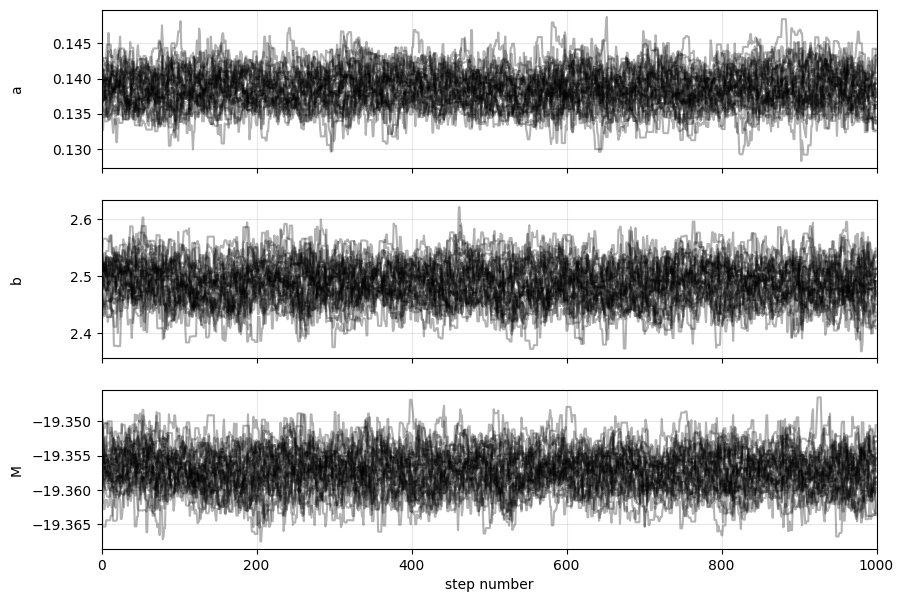

In [24]:
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["a", "b", "M"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [25]:
flat_sample = sampler.get_chain(flat=True)
means = np.mean(flat_sample, axis=0)
print(flat_sample.shape)

(32000, 3)


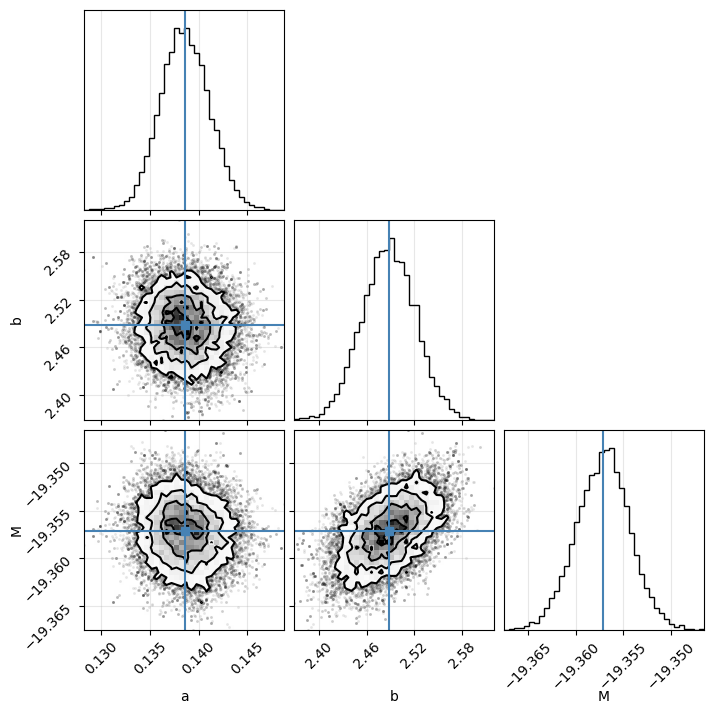

In [26]:
fig = corner.corner(
    flat_sample, labels=labels, 
    truths = means, bins = 40
);

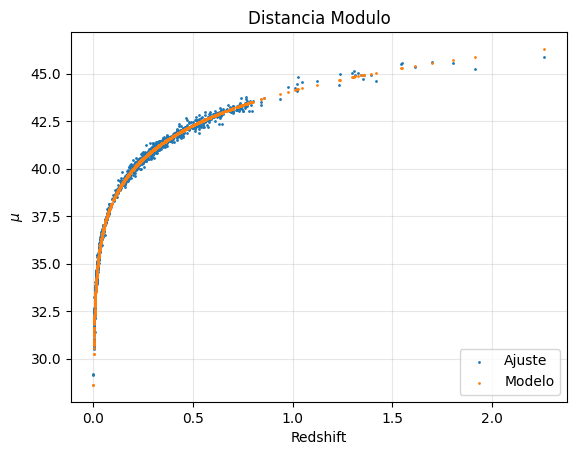

In [27]:
mu_ajus = mb + means[0]*x1- means[1]*color- means[2]
plt.scatter(z, mu_ajus, s = 1, label = 'Ajuste')
plt.scatter(z, mu_i, s = 1, label = 'Modelo')
plt.title('Distancia Modulo')
plt.xlabel('Redshift')
plt.ylabel(r'$\mu$')
plt.legend(loc='lower right')

Notas:
La M tiene una columan al lado? TRUE si fue usado para calibrar. Si la mayoria lo tiene activado, podemos variar H0.
Encontrar expresión para calcular M a partir de los datos. Así podrémos dejar libre H0 y para calcular delta_host

## Universo con curvatura

In [28]:
from astropy.cosmology import LambdaCDM
cosmo_k = LambdaCDM(H0=70, Om0=0.3, Ode0=0.6)   ## de esta manera O_k = 0.1 por la restricción de Friedmann

Analizamos la diferencia entre FlatLCDM y LCD:

In [29]:
dl = cosmo.luminosity_distance(z=1).value   
dl_k = cosmo_k.luminosity_distance(z=1).value   
dl - dl_k                                      ## La distancia luminosa recorrida es mayor para k != 0

192.0187228339637

In [30]:
def Lum_dist (z):
    return cosmo_k.luminosity_distance(z).value

In [31]:
mu_i_k = mu_datos(data['zHD'], H_0, Tcmb_0)

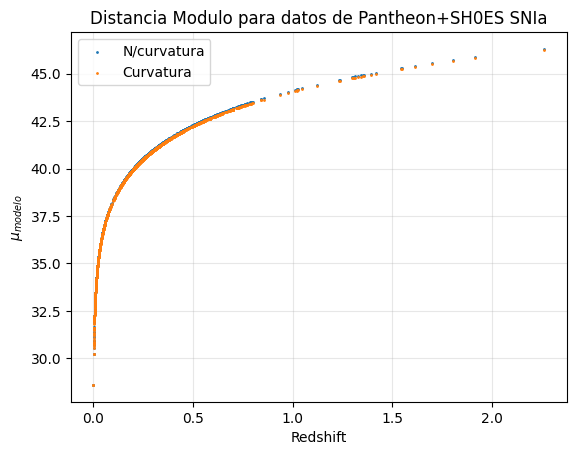

In [32]:
plt.scatter(z, mu_i, s = 1, label = 'N/curvatura')
plt.scatter(z, mu_i_k, s = 1, label = 'Curvatura')
plt.title('Distancia Modulo para datos de Pantheon+SH0ES SNIa')
plt.xlabel('Redshift')
plt.ylabel(r'$\mu_{modelo}$')
plt.legend()

In [33]:
sampler_k = emcee.EnsembleSampler(
    nwalkers, ndim, logPosterior, args=[mu_i_k, cov_matrix_inv,bounds, mb, x1, color]
)

state_k = sampler_k.run_mcmc(pos, 200, progress=True)
sampler_k.reset()
sampler_k.run_mcmc(state_k, 1000, progress=True)
None

100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:19<00:00, 12.61it/s]


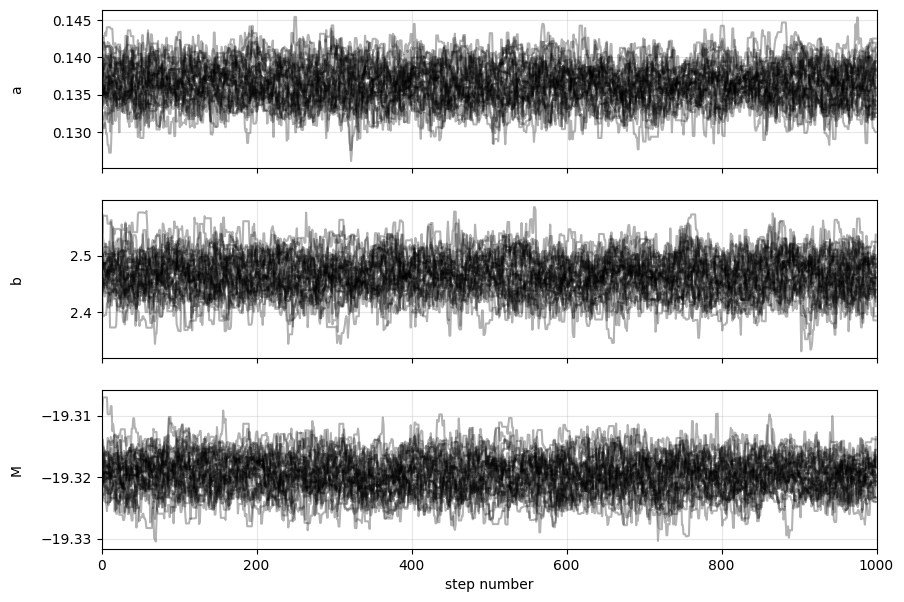

In [34]:
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples_k = sampler_k.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples_k[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples_k))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

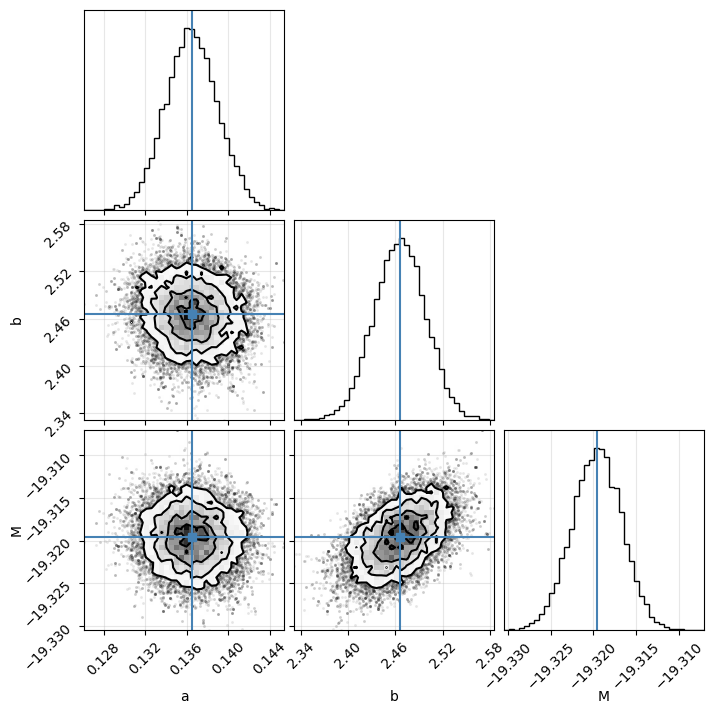

In [35]:
flat_sample_k = sampler_k.get_chain(flat=True)
means_k = np.mean(flat_sample_k, axis=0)
fig = corner.corner(
    flat_sample_k, labels=labels, 
    truths = means_k, bins = 40
);

## Universo wCDM sin curvatura

Describe un modelo cosmológico con energía oscura constante donde la EoS es diferente a $w = -1$.

Usando nuevamente la librería astropy https://docs.astropy.org/en/latest/api/astropy.cosmology.wCDM.html#astropy.cosmology.wCDM

La diferencia de la distancia luminosa en un modelo de DE contante y uno de DE dinpamica es:  198.45760544905988
Distancia luminosa > 0 implica dl > dl_w


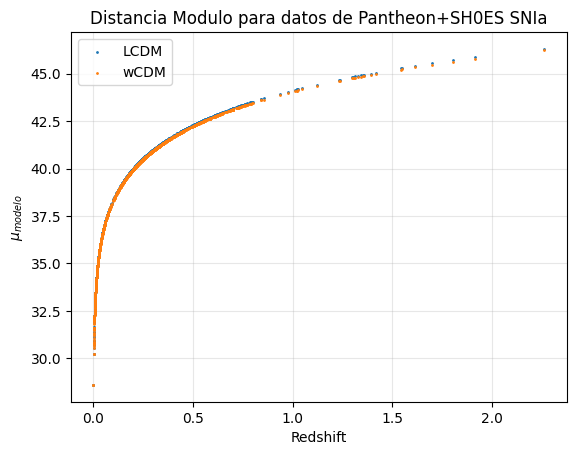

In [36]:
from astropy.cosmology import wCDM
cosmo_w = wCDM(H0=70, Om0=0.3, Ode0=0.7, w0=-0.9)
 
dl_w = cosmo_w.luminosity_distance(z=1).value   
print('La diferencia de la distancia luminosa en un modelo de DE contante y uno de DE dinpamica es: ', (dl-dl_w))
print('Distancia luminosa > 0 implica dl > dl_w')

def Lum_dist (z):
    return cosmo_w.luminosity_distance(z).value

mu_i_w = mu_datos(data['zHD'], H_0, Tcmb_0)

plt.scatter(z, mu_i, s = 1, label = 'LCDM')
plt.scatter(z, mu_i_w, s = 1, label = 'wCDM')
plt.title('Distancia Modulo para datos de Pantheon+SH0ES SNIa')
plt.xlabel('Redshift')
plt.ylabel(r'$\mu_{modelo}$')
plt.legend()

100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:14<00:00, 13.39it/s]


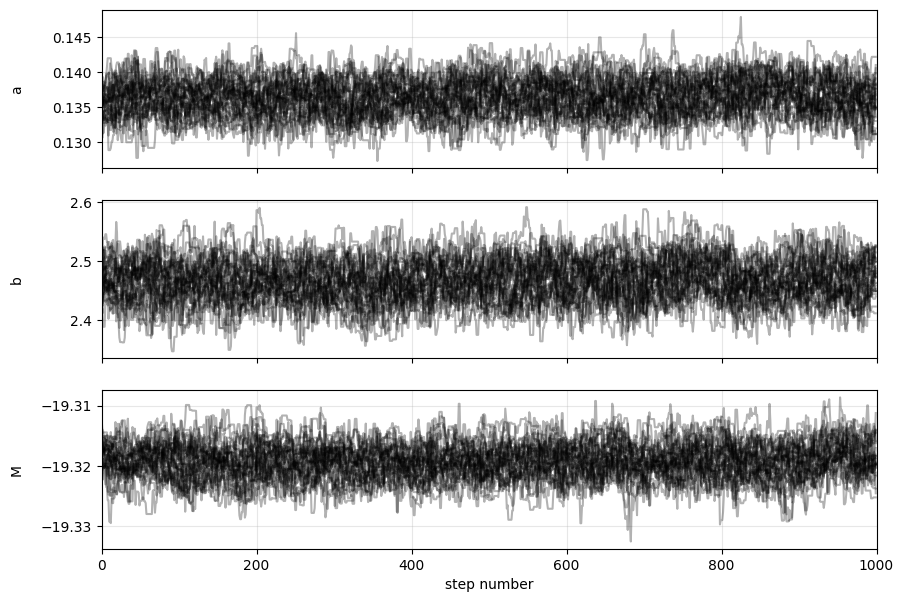

In [37]:
sampler_w = emcee.EnsembleSampler(
    nwalkers, ndim, logPosterior, args=[mu_i_w, cov_matrix_inv,bounds, mb, x1, color]
)

state_w = sampler_w.run_mcmc(pos, 200, progress=True)
sampler_w.reset()
sampler_w.run_mcmc(state_w, 1000, progress=True)
None

fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples_w = sampler_w.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples_w[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples_w))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

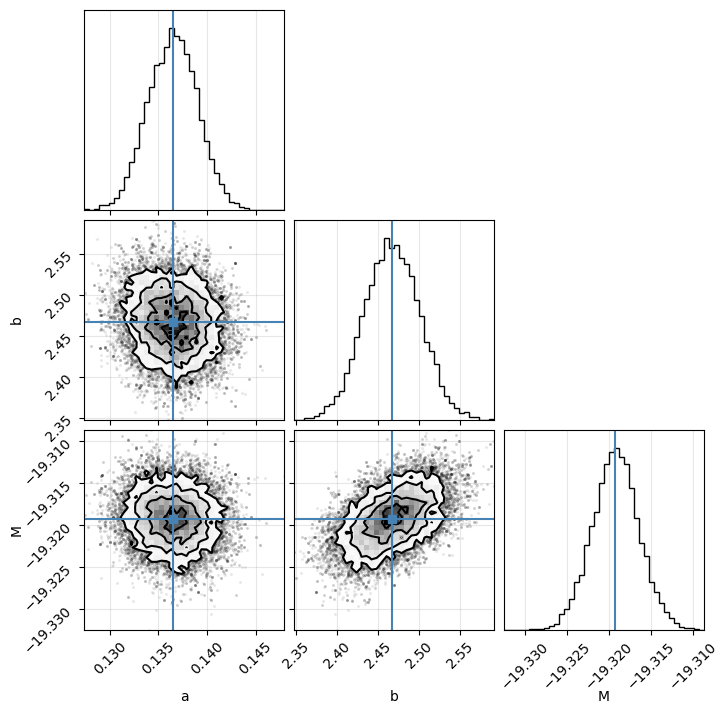

In [38]:
flat_sample_w = sampler_w.get_chain(flat=True)
means_w = np.mean(flat_sample_w, axis=0)
fig = corner.corner(
    flat_sample_w, labels=labels, 
    truths = means_w, bins = 40
);

El modelo varía muy poco respecto al ejemplo anterior dado que los parámetros de densidad (a pesar de que la EoS es diferente en DE y la curvatura), son muy similares a LCDM con curvatura. La variación más grande es en el parámetro $\beta$.

## Universo w0waCDM

Un universo con DE dinámica en el tiempo! La dinámica está dada por el parámetro $w_a$ que acompaña una $f(a)$ que es simplemente $w_a(a+1)$.

https://docs.astropy.org/en/latest/api/astropy.cosmology.w0waCDM.html#astropy.cosmology.w0waCDM

La diferencia de la distancia luminosa en un modelo de DE contante y uno de DE dinpamica es:  249.16471597373584
Distancia luminosa > 0 implica dl > dl_a


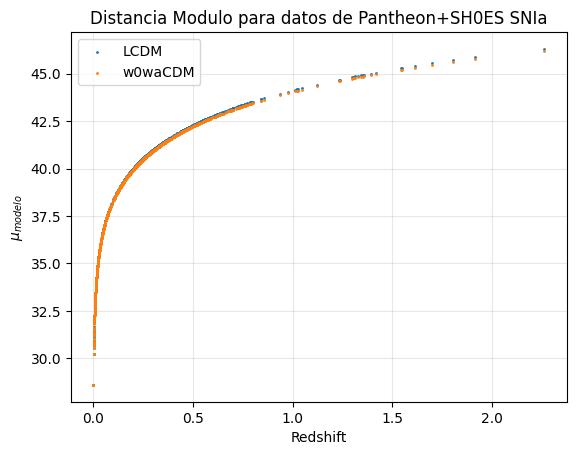

In [39]:
from astropy.cosmology import w0waCDM
cosmo_wa = w0waCDM(H0=70, Om0=0.3, Ode0=0.7, w0=-0.9, wa=0.2)

dl_wa = cosmo_wa.luminosity_distance(z=1).value   
print('La diferencia de la distancia luminosa en un modelo de DE contante y uno de DE dinpamica es: ', (dl-dl_wa))
print('Distancia luminosa > 0 implica dl > dl_a')

def Lum_dist (z):
    return cosmo_wa.luminosity_distance(z).value

mu_i_wa = mu_datos(data['zHD'], H_0, Tcmb_0)

plt.scatter(z, mu_i, s = 1, label = 'LCDM')
plt.scatter(z, mu_i_wa, s = 1, label = 'w0waCDM')
plt.title('Distancia Modulo para datos de Pantheon+SH0ES SNIa')
plt.xlabel('Redshift')
plt.ylabel(r'$\mu_{modelo}$')
plt.legend()

100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:27<00:00, 11.46it/s]


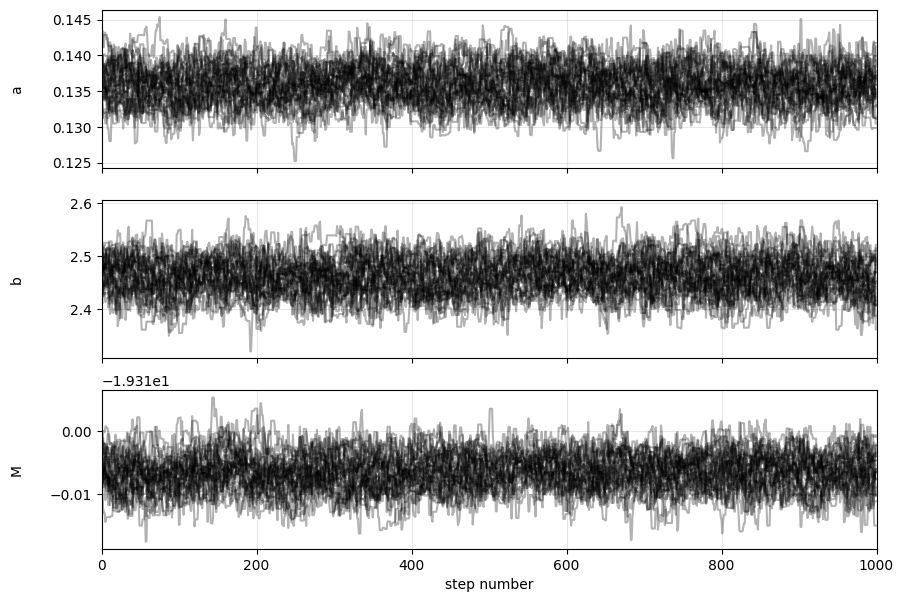

In [40]:
sampler_wa = emcee.EnsembleSampler(
    nwalkers, ndim, logPosterior, args=[mu_i_wa, cov_matrix_inv,bounds, mb, x1, color]
)

state_wa = sampler_wa.run_mcmc(pos, 200, progress=True)
sampler_wa.reset()
sampler_wa.run_mcmc(state_wa, 1000, progress=True)
None

fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples_wa = sampler_wa.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples_wa[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples_wa))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

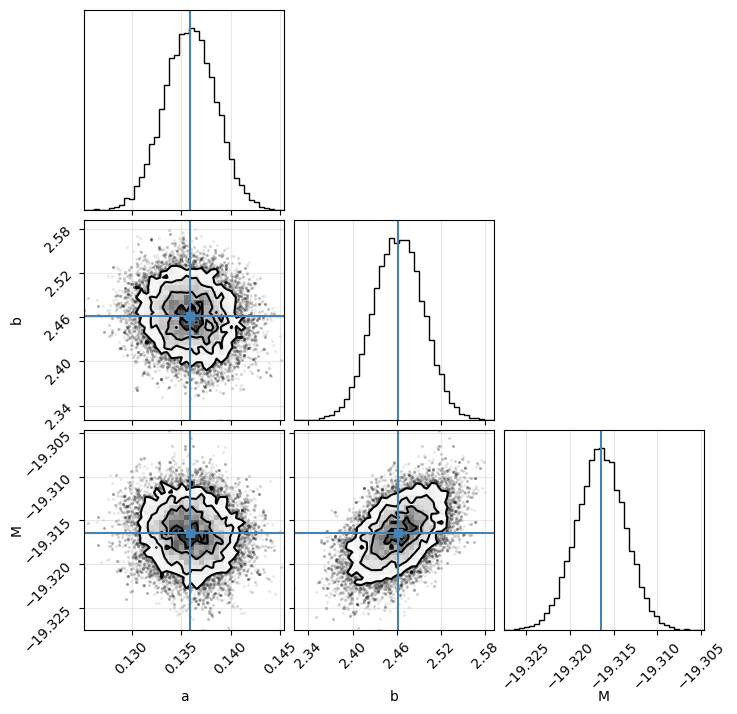

In [41]:
flat_sample_wa = sampler_wa.get_chain(flat=True)
means_wa = np.mean(flat_sample_wa, axis=0)
fig = corner.corner(
    flat_sample_wa, labels=labels, 
    truths = means_wa, bins = 40
);

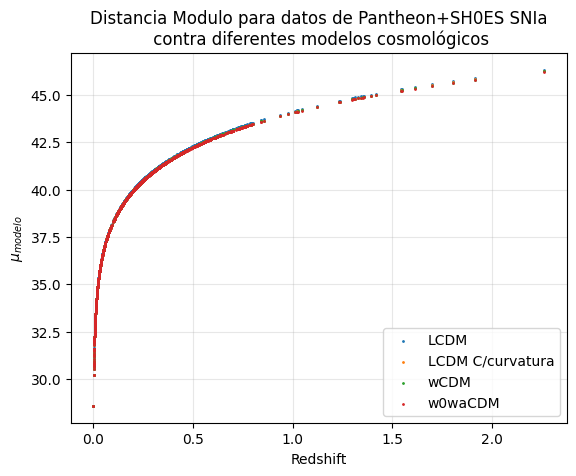

In [46]:
plt.scatter(z, mu_i, s = 1, label = 'LCDM')
plt.scatter(z, mu_i_k, s = 1, label = 'LCDM C/curvatura')
plt.scatter(z, mu_i_w, s = 1, label = 'wCDM')
plt.scatter(z, mu_i_wa, s = 1, label = 'w0waCDM')
plt.title('Distancia Modulo para datos de Pantheon+SH0ES SNIa\n contra diferentes modelos cosmológicos')
plt.xlabel('Redshift')
plt.ylabel(r'$\mu_{modelo}$')
plt.legend()

In [44]:
print(means)
print(means_k)
print(means_w)
print(means_wa)

[  0.13859883   2.48768079 -19.35715405]
[  0.13647716   2.46538029 -19.31960878]
[  0.13646131   2.46713209 -19.31921684]
[  0.13587932   2.46194414 -19.31648364]


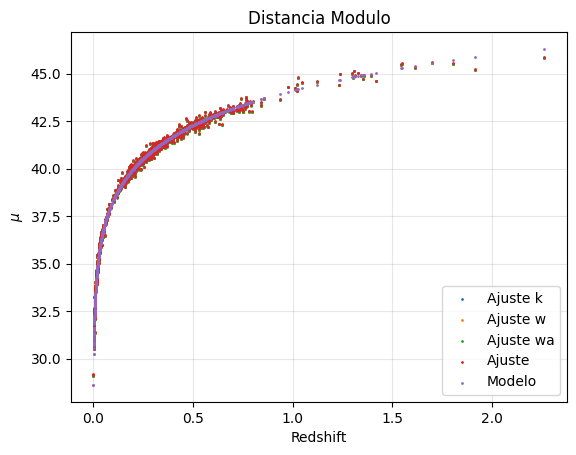

In [48]:
## Distancia modulo para los parámetros ajustados
mu_ajus = mb + means[0]*x1- means[1]*color- means[2]
mu_ajus_k = mb + means_k[0]*x1- means_k[1]*color- means_k[2]
mu_ajus_w = mb + means_w[0]*x1- means_w[1]*color- means_w[2]
mu_ajus_wa = mb + means_wa[0]*x1- means_wa[1]*color- means_wa[2]
plt.scatter(z, mu_ajus_k, s = 1, label = 'Ajuste k')
plt.scatter(z, mu_ajus_w, s = 1, label = 'Ajuste w')
plt.scatter(z, mu_ajus_wa, s = 1, label = 'Ajuste wa')
plt.scatter(z, mu_ajus, s = 1, label = 'Ajuste')
plt.scatter(z, mu_i, s = 1, label = 'Modelo')
plt.title('Distancia Modulo')
plt.xlabel('Redshift')
plt.ylabel(r'$\mu$')
plt.legend(loc='lower right')

Notas: 
- Hay que varíar un poco más los parámetros para ver cambios reales en los ajustes
- Cambiar H0 y Tcmb0 de WMAP9?
- Dejar M libre?
- Agregar deltas
- Agregar cov_syst